<a href="https://colab.research.google.com/github/dafnalj/dafnalj.github.io/blob/main/Ephys_Analysis_PeterK_DAF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#pyABF is a Python package for reading electrophysiology data from Axon Binary Format (ABF) files.

Input: .abf files into the content

In [ ]:
!pip install pyabf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 801.8 kB/s eta 0:00:00


# Table of all the data

Including: Protocol,	Sweep Number,	Duration (s),	Duration (min).


In [ ]:
import pyabf
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

# Set seaborn style for better visualization
sns.set(style="whitegrid")

# Define the main directory for data files
data_dir = '/content/'


# Step 1: Load datasets and read header information
def list_abf_files(directory):
    """
    List all .abf files in the specified directory.
    """
    if os.path.exists(directory):
        abf_files = [f for f in os.listdir(directory) if f.endswith('.abf')]
        return abf_files
    else:
        print("The directory does not exist.")
        return []

# Step 2: Extract and display protocol information
def compile_protocol_info(directory):
    protocol_info = []
    abf_files = [f for f in os.listdir(directory) if f.endswith('.abf')]

    for abf_file in abf_files:
        abf_path = os.path.join(directory, abf_file)
        abf = pyabf.ABF(abf_path)
        protocol_name = abf.protocol
        sweep_number = len(abf.sweepList)
        recording_duration_seconds = abf.dataLengthSec
        recording_duration_minutes = recording_duration_seconds / 60  # Convert to minutes
        protocol_info.append((abf_file, protocol_name, sweep_number, recording_duration_seconds, recording_duration_minutes))

    df = pd.DataFrame(protocol_info, columns=['File Name', 'Protocol', 'Sweep Number', 'Duration (s)', 'Duration (min)'])
    sorted_df = df.sort_values(by='Protocol')

    return sorted_df

In [ ]:
#print the list to check
list_abf_files(data_dir)
compile_protocol_info(data_dir)

,File Name,Protocol,Sweep Number,Duration (s),Duration (min)
0,2024_08_27_0005.abf,Electrical Stim baseline,98,491.430022,8.190500
1,2024_08_28_0013.abf,Peter Mon VC,1,2.355200,0.039253


In [ ]:
abf = pyabf.ABF("2024_08_28_0013.abf")
print(abf)


ABF (v2.9) with 1 channel (pA), sampled at 20.0 kHz, containing 1 sweep, having 1 tag (HumSilencer : On), with a total length of 0.04 minutes, recorded with protocol "Peter Mon VC".


# Visualising CC DATA

In [ ]:
abf = pyabf.ABF("2024_08_28_0013.abf")


In [ ]:
def read_abf_comments(file_path):
    with open("2024_08_28_0013.abf", 'rb') as file:
        # Read the file signature to confirm it's an ABF file
        file_signature = file.read(4)
        if file_signature != b'ABF ':


        # Seek to the FileComment section
        file.seek(0xAC)  # FileComment is located at byte offset 0xAC in ABF v1.0

        # Read the FileComment (256 bytes long)
        raw_comment = file.read(256)
        try:
            # Attempt to decode using UTF-8
            comment = raw_comment.decode('utf-8').strip()
        except UnicodeDecodeError:
            # Fallback if UTF-8 decoding fails
            comment = raw_comment.decode('latin-1').strip()
        return comment

# Usage
abf_file_path = "2024_08_28_0013.abf"
comment = read_abf_comments(abf_file_path)
print("Comment from ABF file:", comment)



IndentationError: expected an indented block after 'if' statement on line 5 (<ipython-input-53-08e411a3f428>, line 9)

In [ ]:
# Step 3: Visualize data based on protocol

#plot all sweeps in abf file

def plot_all_sweeps(abf):
  plt.figure(figsize=(5, 3))
  plt.title(f"All Sweeps - Protocol: {abf.protocol}")
  plt.xlabel(abf.sweepLabelX)
  plt.ylabel(abf.sweepLabelY)

  for sweep in abf.sweepList:
    abf.setSweep(sweep)
    plt.plot(abf.sweepX, abf.sweepY, alpha = 0.5, label=f"Sweep {sweep}")

  #plt.legend(loc='upper right')
  plt.show()


def plot_sweep(abf, sweep_numbers, protocol_name):
    """
    Plot selected sweeps for a given protocol.
    """
    plt.figure(figsize=(5, 3))
    plt.title(protocol_name)
    plt.ylabel(abf.sweepLabelY)
    plt.xlabel(abf.sweepLabelX)
    for sweep in sweep_numbers:
        abf.setSweep(sweep)
        plt.plot(abf.sweepX, abf.sweepY, alpha=.8, label=f"sweep {sweep}")
    plt.legend()
    plt.show()


def plot_waveform(abf, sweep_number):
    """
    Plot ADC (voltage recording) and DAC (stimulus waveform) for a selected sweep.
    """
    abf.setSweep(sweep_number)
    fig = plt.figure(figsize=(5, 3))

    # Plot the ADC (voltage recording)
    ax1 = fig.add_subplot(211)
    ax1.set_title("ADC (recorded waveform)")
    ax1.plot(abf.sweepX, abf.sweepY)

    # Plot the DAC (clamp current)
    ax2 = fig.add_subplot(212, sharex=ax1)
    ax2.set_title("DAC (stimulus waveform)")
    ax2.plot(abf.sweepX, abf.sweepC, color='r')

    ax1.set_ylabel(abf.sweepLabelY)
    ax2.set_xlabel(abf.sweepLabelX)
    ax2.set_ylabel(abf.sweepLabelC)
    ax1.axes.set_xlim(0, 2)
    plt.show()


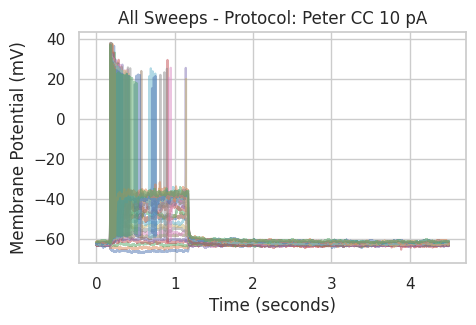

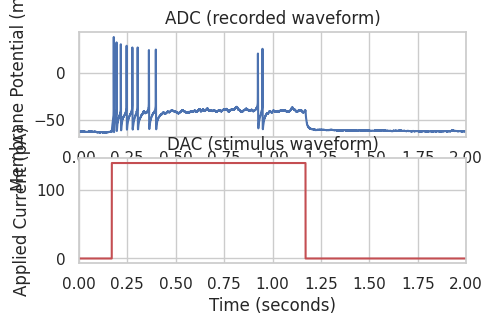

In [ ]:
example_abf = pyabf.ABF("2024_07_25_0041.abf")
plot_all_sweeps(example_abf)
plot_waveform(example_abf, 16)

In [ ]:
def analyze_recordings(data_dir, group_with_ne, group_without_ne):
    """
    Analyze recordings by calculating the number of spikes for each sweep in the provided groups.
    """
    abf_files = list_abf_files(data_dir)
    filtered_files = [f for f in abf_files if "Peter CC 10 pA" in pyabf.ABF(os.path.join(data_dir, f)).protocol]

    d_all = []
    for filename in filtered_files:
        abf = pyabf.ABF(os.path.join(data_dir, filename))
        sweep_data = [abf.setSweep(sweep) or abf.sweepY for sweep in range(abf.sweepCount)]
        d_all.append(sweep_data)

    cell_rows = [i for i, data in enumerate(d_all) if len(data) >= 15 and data[14] is not None]
    n_cells = len(cell_rows)
    nsteps = max(len(data) for data in d_all)

    spikedata = np.full((nsteps, n_cells), np.nan)

    # Calculate the number of spikes within each step
    lim1, lim2 = 8000, 62500
    for i, row in enumerate(cell_rows):
        for ji in range(nsteps):
            if ji < len(d_all[row]):
                spkdata = d_all[row][ji]
                if spkdata is not None:
                    spkdata = spkdata[lim1:lim2]
                    signdata = np.sign(spkdata)
                    sdata2 = np.where(signdata > 0)[0]
                    nsd = len(sdata2)

                    if nsd > 1:
                        intervals = np.diff(sdata2)
                        n_spikes = np.sum(intervals > 1) + 1
                    else:
                        n_spikes = 0

                    spikedata[ji, i] = n_spikes

    def extract_events(group):
        return [spikedata[ji, filtered_files.index(filename)] for filename in group if filename in filtered_files for ji in range(nsteps)]

    events_with_ne = extract_events(group_with_ne)
    events_without_ne = extract_events(group_without_ne)

    avg_events_with_ne = np.nanmean(events_with_ne)
    std_events_with_ne = np.nanstd(events_with_ne)
    avg_events_without_ne = np.nanmean(events_without_ne)
    std_events_without_ne = np.nanstd(events_without_ne)

    return avg_events_with_ne, std_events_with_ne, avg_events_without_ne, std_events_without_ne

def plot_analysis_results(avg_events_with_ne, std_events_with_ne, avg_events_without_ne, std_events_without_ne):
    """
    Plot the results of the analysis comparing the number of spikes with and without NE.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot with error bars
    ax1.bar('With NE', avg_events_with_ne, yerr=std_events_with_ne, capsize=5, color='blue', label='With NE')
    ax1.bar('Without NE', avg_events_without_ne, yerr=std_events_without_ne, capsize=5, color='green', label='Without NE')

    ax1.set_ylabel("Average Number of Spikes")
    ax1.set_title("Average Number of Spikes with and without NE")
    ax1.legend()

    plt.tight_layout()
    plt.show()


# To plot OPTO PROTOCOL

In [ ]:
def plot_opto_protocol(abf_file_path):
    """
    Plot all sweeps and the average sweep from a single ABF file for the 'Opto' protocol.

    Args:
        file (str): Path to the ABF file.
    """
    abf = pyabf.ABF(abf_file_path)
    abf.setSweep(1)  # Initialize sweep data

    # Initialize arrays to accumulate data
    sweepX = abf.sweepX
    num_sweeps = abf.sweepCount
    sweepY_sum = np.zeros_like(abf.sweepY)

    # Plot individual sweeps and average
    fig, ax = plt.subplots(figsize=(6, 4))

    # Plot individual sweeps
    for sweep in abf.sweepList:
        abf.setSweep(sweep)
        ax.plot(abf.sweepX, abf.sweepY, color='grey', alpha=0.9)  # Individual sweeps in light grey
        sweepY_sum += abf.sweepY

    # Compute and plot the average sweep
    average_sweepY = sweepY_sum / num_sweeps
    ax.plot(sweepX, average_sweepY, color='black', linewidth=2, label='Average Sweep')

    # Set axis limits to zoom in on the desired time range
    ax.set_xlim(0, 0.6)

    # Set labels, title, and legend
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('current(pA)')
    ax.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()


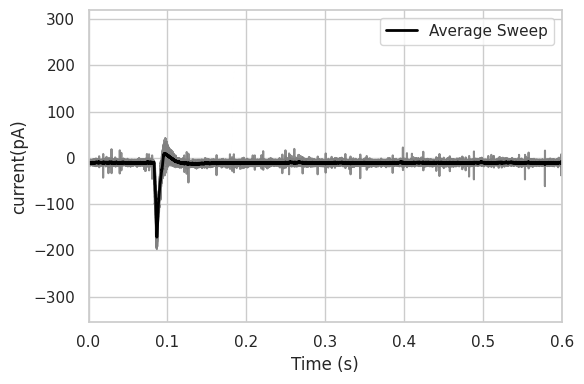

ABF (v2.9) with 1 channel (pA), sampled at 20.0 kHz, containing 18 sweeps, having 1 tag (HumSilencer : On), with a total length of 3.03 minutes, recorded with protocol "Peter Opto 5 ms single ON 81.3".


In [ ]:
plot_opto_protocol("2024_07_25_0058.abf")
a = pyabf.ABF("2024_07_25_0058.abf")
print(a)


In [ ]:
# Function to load a single sweep from an ABF file
def load_single_sweep_abf(filename, sweep_number=0, voltage_channel=0):
    abf = pyabf.ABF(filename)
    abf.setSweep(sweep_number, voltage_channel)
    return abf.sweepX, abf.sweepY, abf.sweepLabelY

def plot_vc_protocol(abf_file_path):
    """
    Plot a single sweep from a single ABF file for the 'VC' protocol.

    Args:
        abf_file_path (str): Path to the ABF file.
    """
    # Load the sweep data
    sweepX, sweepY, labelY = load_single_sweep_abf(abf_file_path)

    # Create a figure for the plot
    plt.figure(figsize=(6, 4))

    # Plot the single sweep data
    plt.plot(sweepX, sweepY, label=os.path.basename(abf_file_path))
    plt.ylabel(labelY)
    plt.title('Single Sweep Voltage Clamp Data')

    # Set axis limits (customize if necessary)
    plt.xlim(0, 70)  # Adjust based on the expected time range
    plt.xlabel('Time (s)')

    # Layout adjustments
    plt.tight_layout()

    # Show the plot
    plt.show()


# To plot ALL based on the protocol

In [ ]:
plot_vc_protocol("2024_07_25_0058.abf")

In [ ]:
def handle_files(directory):
  abf_files = list_abf_files(directory)
  for filename in abf_files:
    abf_path = os.path.join(directory, filename)
    abf = pyabf.ABF(abf_path)
    protocol_name = abf.protocol

    if "CC" in protocol_name:
      plot_all_sweeps(abf) # or plot_sweep if specific sweeps are needed

    elif "Opto" in protocol_name:
      plot_opto_protocol(abf_path)

    elif "VC" in protocol_name:
      plot_vc_protocol(abf_path)

    else:
      print(f"Protocol '{protocol_name}' not recognized for special handling.")

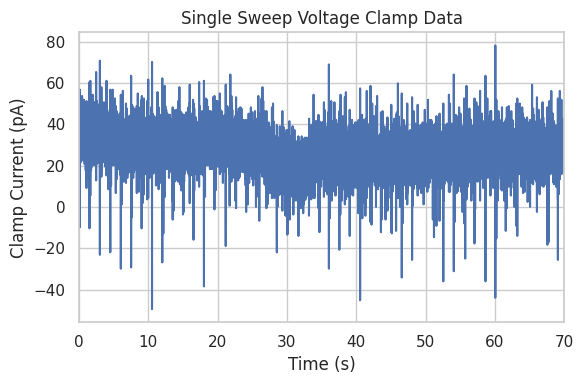

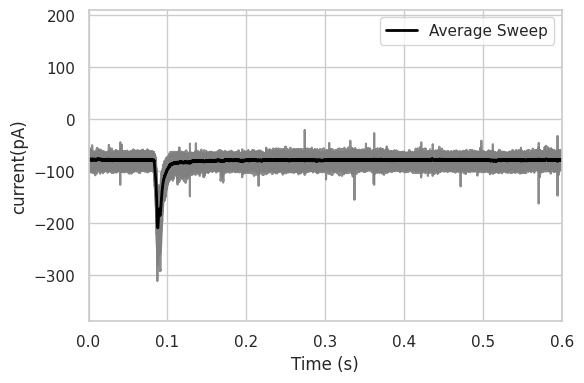

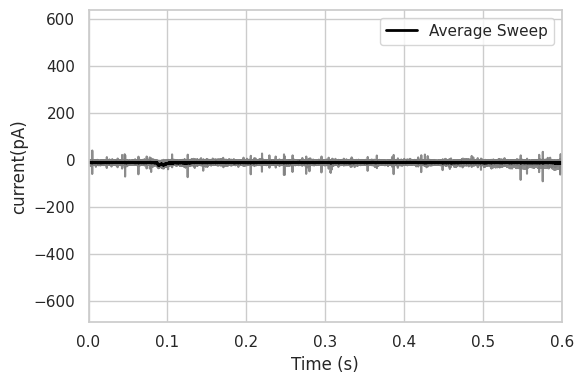

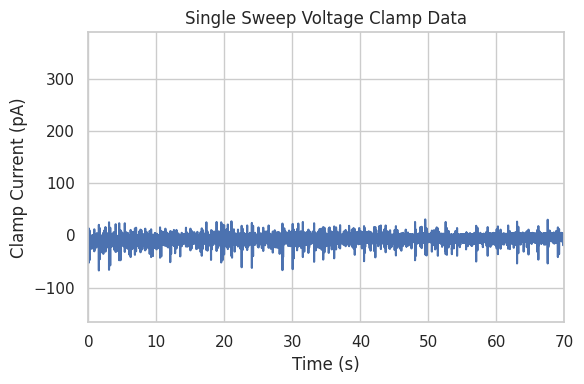

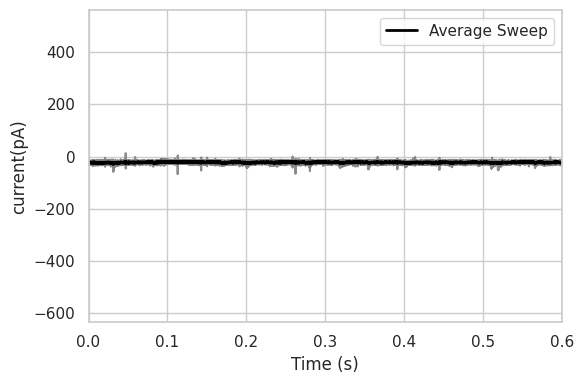

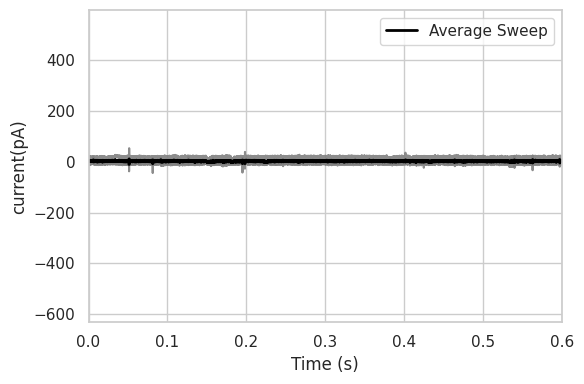

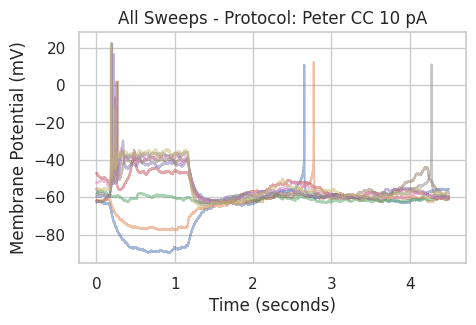

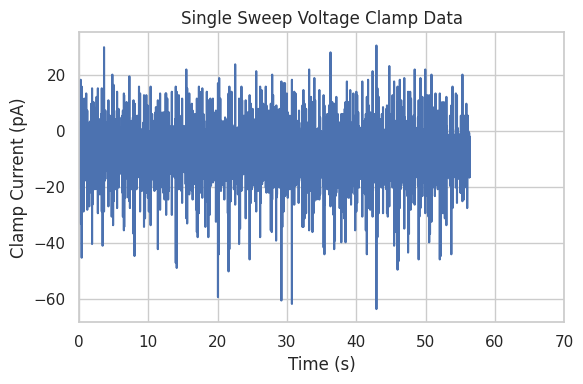

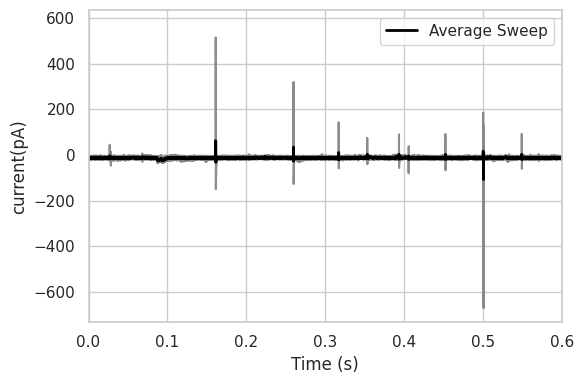

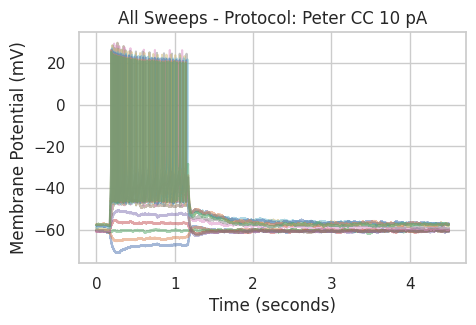

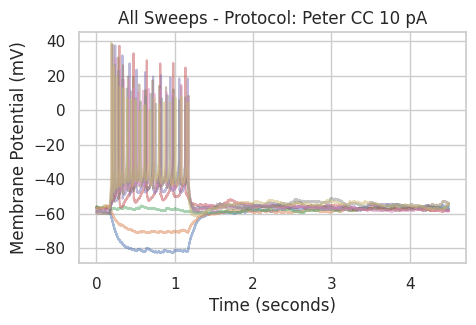

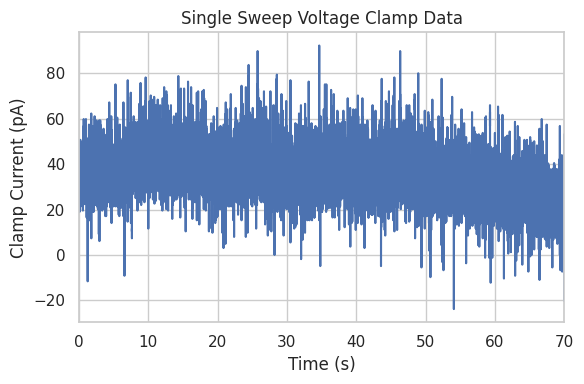

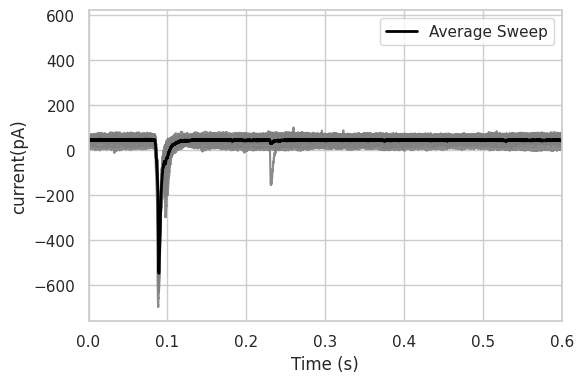

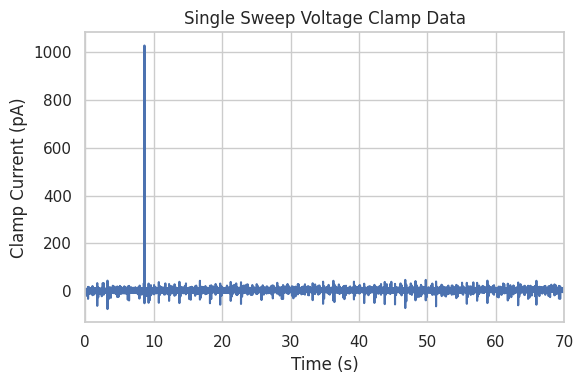

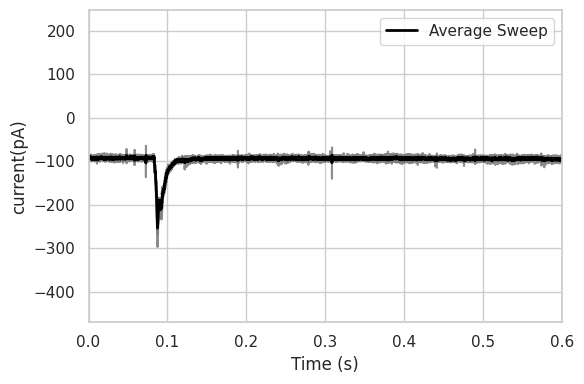

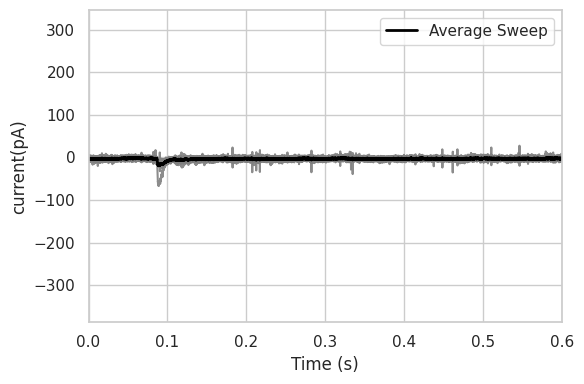

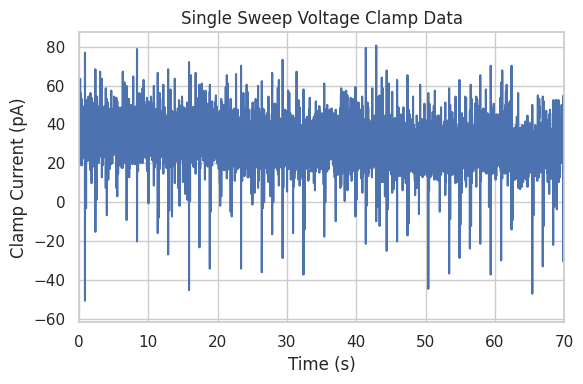

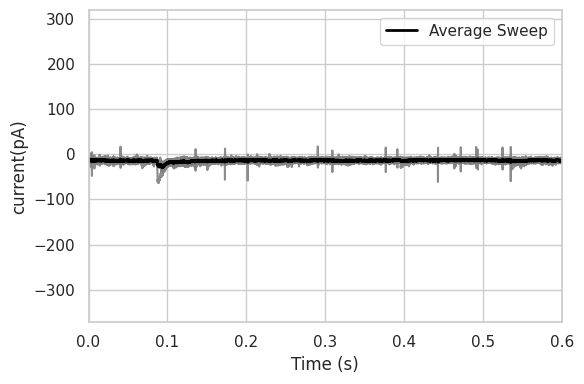

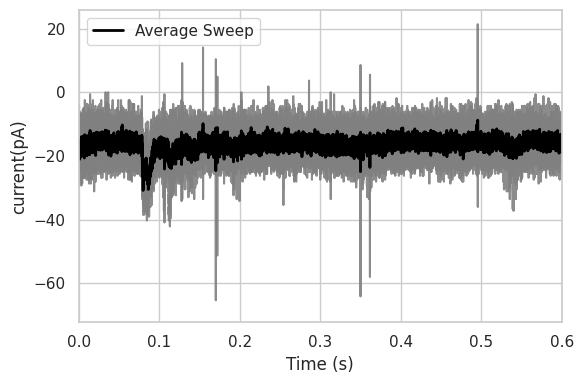

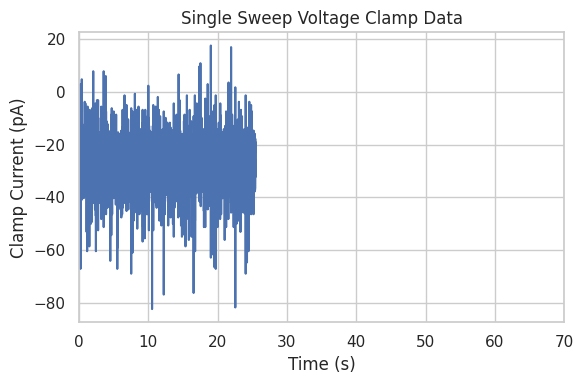

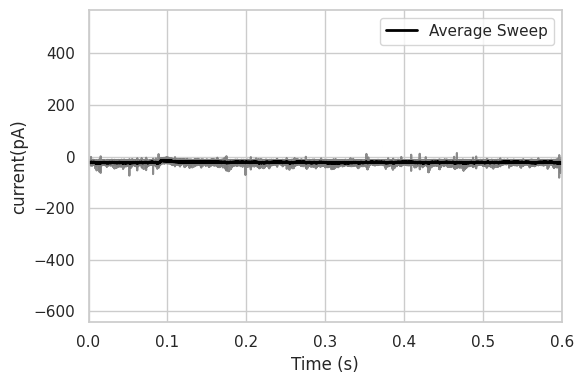

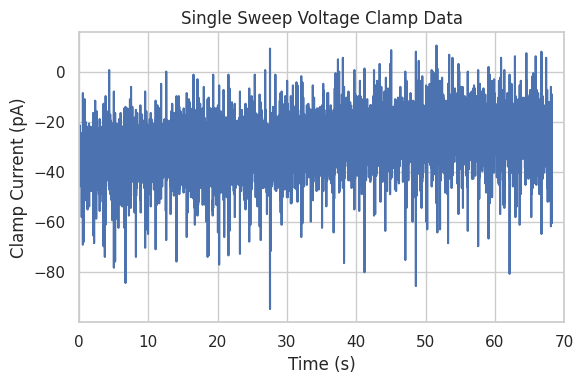

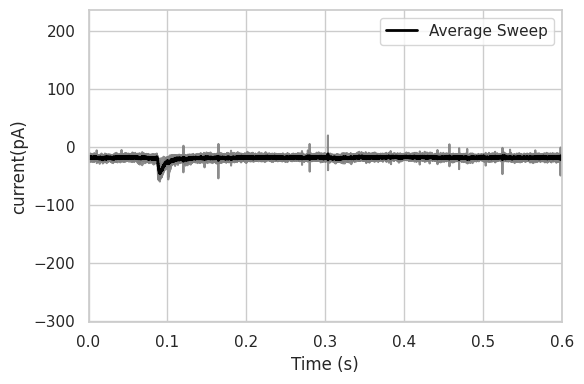

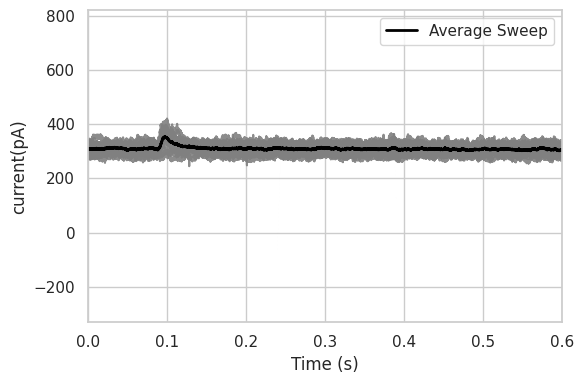

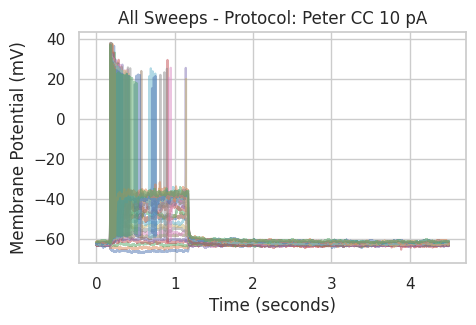

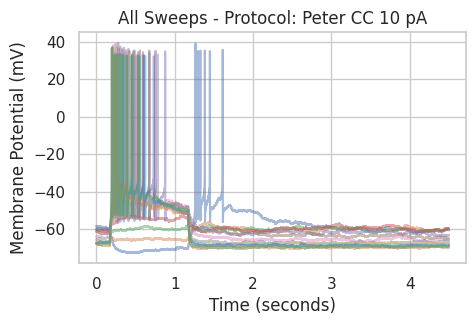

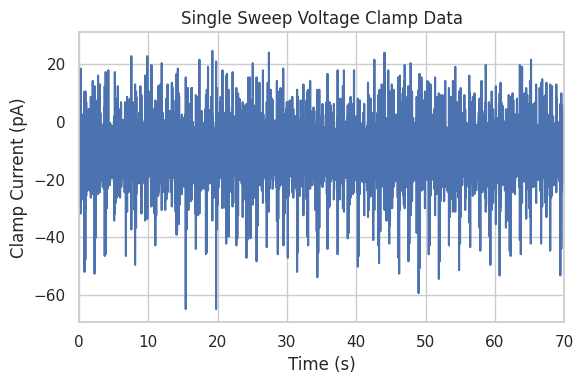

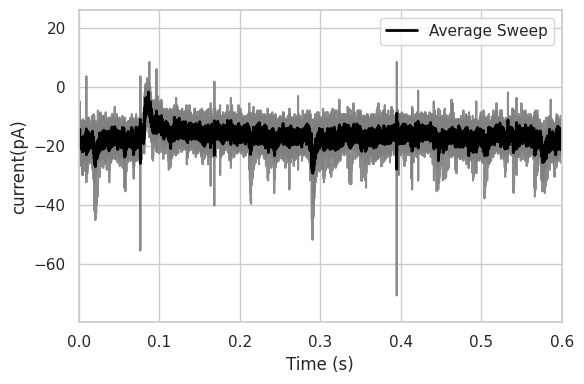

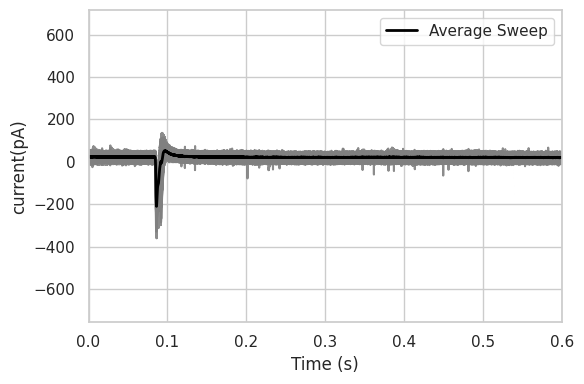

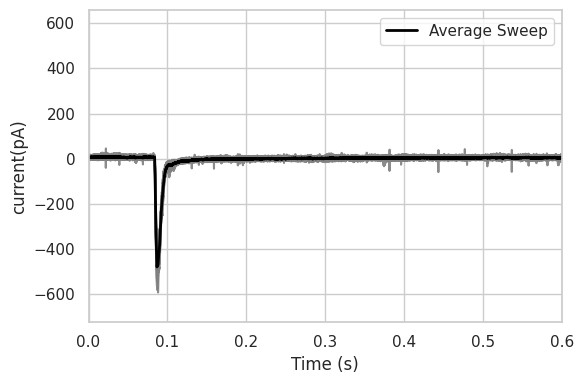

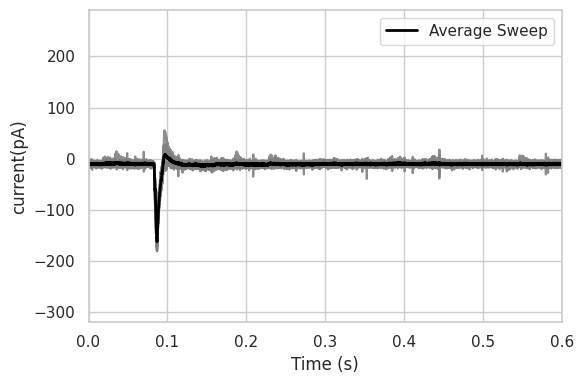

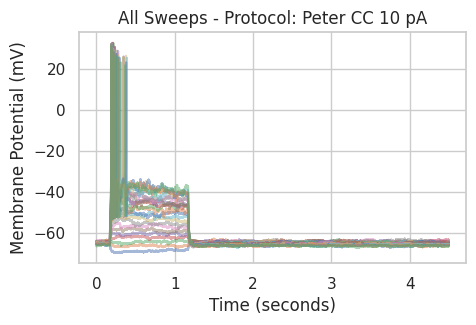

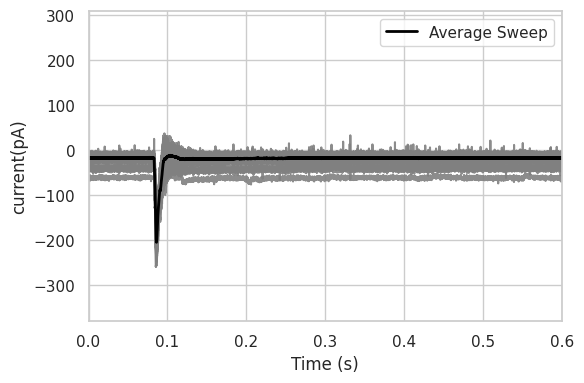

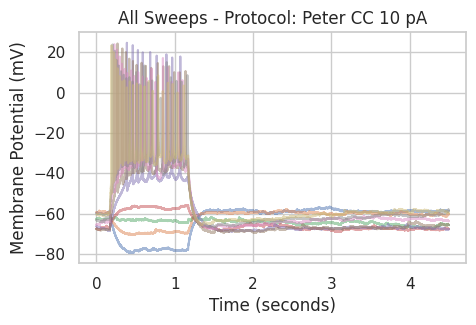

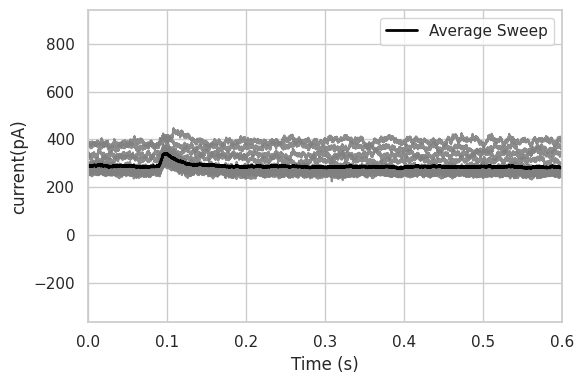

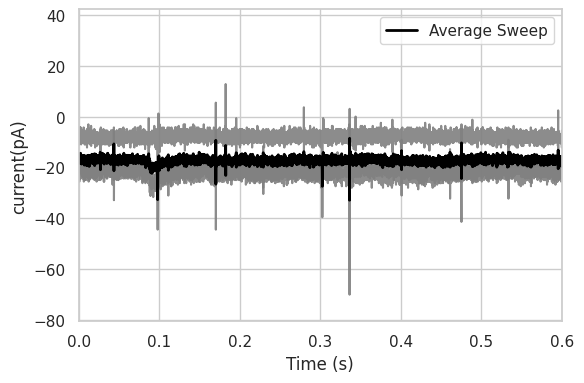

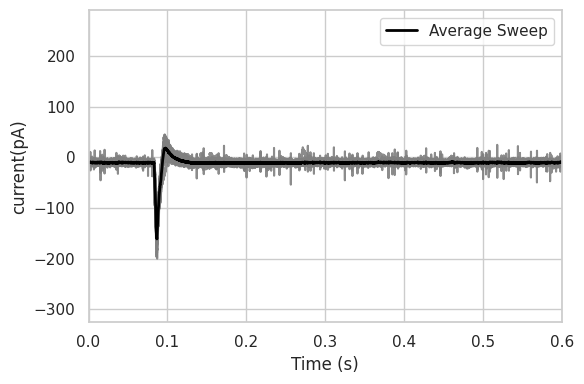

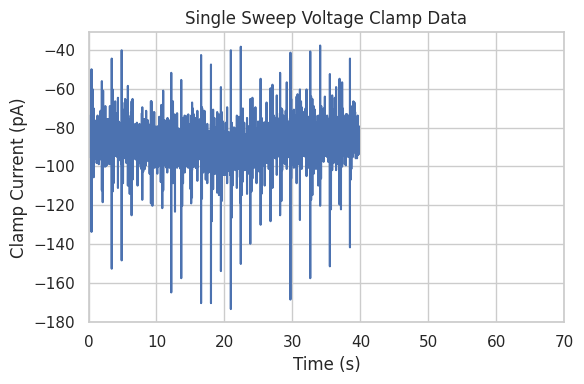

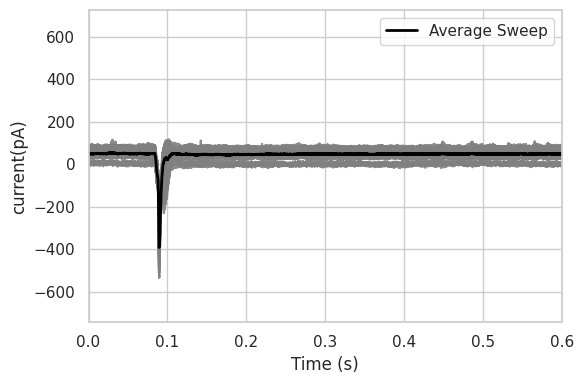

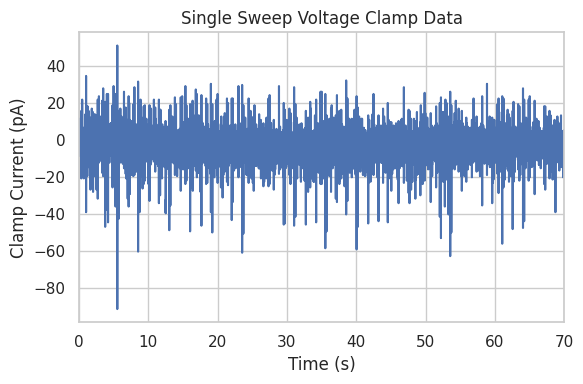

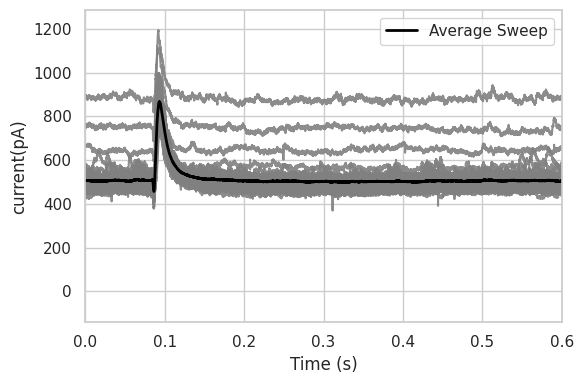

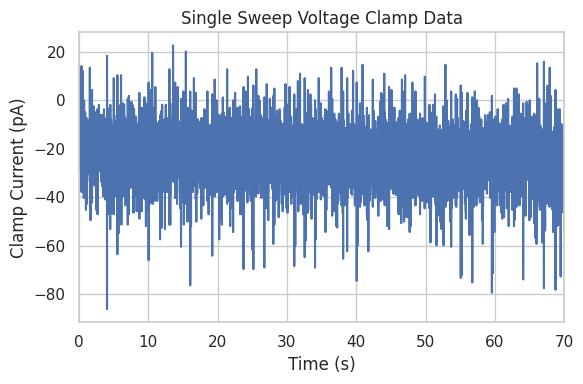

ValueError: Sweep 1 not available (must be 0 - 0)

In [ ]:
handle_files(data_dir)